## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

 Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 0

If students address the detailed feedback in a future checkpoint they will earn these points back






|                                  | **Unsatisfactory**                                                                                                                                                                                                                                                                                                                        | **Developing**                                                                                                                                                                                                       | **Proficient**                                                                                                                                                                                            | **Excellent**                                                                                                                                                                            |
|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA relevance**                | EDA is mostly neither relevant to the question nor helpful in figuring out how to address the question. Or the EDA does address the question, but many obviously relevant variables / analyses / figures were not included. | EDA is partly irrelevant/unhelpful. EDA missed one or two obvioulsy relevant analysis (distributions of single variables or relationships between variables) | EDA includes the obviously relevant / helpful variables in addressing the question.                                                              | Thorough EDA fully explored the dataset                                                                                                                 |
| **EDA analysis and description** | Many of the analyses are poor choices (e.g., using means instead of medians for obviously skewed data), or are poorly described in the text, or do not aid understanding the data                                                                                                                                                     | Some of the analyses are poor choices, or are poorly described in the text, or do not aid understanding the data                                                                                                 | All analyses are correct choices. Only one or two have minor issues in the text descriptions supporting them. Mostly they fit well with other elements of the EDA and support understanding the data  | All analyses are correct choices with clear text descriptions supporting them. The figures fit well with the other elements of the EDA, producing a clear understanding of the data. |
| **EDA figures**                  | Many of the figures are poor plot choices (e.g., using a bar plot to represent a time series where it would be better to use a line plot) or have poor aesthetics (including colormap, data point shape/color, axis labels, titles, annotations, text legibility) or do not aid understanding the data                                | Some of the figures are poor plot choices or have poor aesthetics. Some figures do not aid understanding the data                                                                                                | All figures are correct plot choices. Only one or two have minor questionable aesthetic choices. The figures mostly fit well with the other elements of the EDA and support understanding the data    | All figures are correct plot choices with beautiful aesthetics. The figures fit well with the other elements of the EDA, producing a clear understanding of the data.                |





# COGS 108 - EDA Checkpoint

## Authors

Instructions: REPLACE the contents of this cell with your team list and their contributions. Note that this will change over the course of the checkpoints

This is a modified [CRediT taxonomy of contributions](https://credit.niso.org). For each group member please list how they contributed to this project using these terms:
> Analysis, Background research, Conceptualization, Data curation, Experimental investigation, Methodology, Project administration, Software, Visualization, Writing – original draft, Writing – review & editing

Example team list and credits:
- Alice Anderson: Conceptualization, Data curation, Methodology, Writing - original draft
- Bob Barker:  Analysis, Software, Visualization
- Charlie Chang: Project administration, Software, Writing - review & editing
- Dani Delgado: Analysis, Background research, Visualization, Writing - original draft

# Research Question

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback



## Background and Prior Work

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

# Hypothesis


Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Data

### Data Overview  
#### 1. Ideal Dataset

The ideal dataset would contain tract-level data for **San Diego County** for a given year (2022), providing a sufficient number of observations for tract-level modeling and statistical inference. These data would be collected by official agencies with access to verified administrative or utility records. Each observation would include variables on household income, direct residential energy consumption (kWh for electricity, therms for natural gas, etc.), and relevant demographic and housing characteristics. Ideally, carbon emissions would be directly measured in metric tons of CO₂ per tract. The dataset would be clean, tidy, and tabular, with standardized procedures, clearly labeled variables, and minimal missingness. Each row would correspond to a census tract to allow granular, neighborhood-level analysis.

---

#### 2. Real Dataset

The dataset used in this project is publicly available at:  
https://data.openei.org/submissions/6219  

It provides census tract–level data for all of California from the **Low-Income Energy Affordability Data (LEAD) Tool – 2022 Update**. The dataset includes detailed measurements of income and residential energy expenditures. The key variables relevant to this project include:

- **AMI150**: Area Median Income grouping  
- **HINCP*UNITS**: Sum of average annual household income multiplied by number of units (used to compute total tract income and average income per household)
- **UNITS**: Number of households  
- **ELEP*UNITS**: Total electricity expenditures  
- **GASP*UNITS**: Total natural gas expenditures  
- **FULP*UNITS**: Total other fuel expenditures  

While carbon emissions are not explicitly included in the dataset, we estimate residential carbon emissions by converting these energy expenditures into physical energy use and then applying official emissions factors specific to San Diego in 2022.

Specifically, for each San Diego census tract:

1. We aggregate expenditure totals and household counts across income bins to produce one observation per tract.
2. We convert expenditures into estimated energy use using 2022 SDG&E residential price scalars.
3. We convert estimated energy use into CO₂ emissions using EPA emissions factors.
4. We normalize emissions by the number of households to obtain **estimated kg CO₂ per household per year**.

Formally:

kWh_t = ElecExp_t / P_elec,SD2022  

Therms_t = GasExp_t / P_gas,SD2022  

CO2e_t = (kWh_t × EF_elec,2022) + (Therms_t × EF_gas)  

CO2ePerHH_t = CO2e_t / UNITS_t  

Where:

- **P_elec,SD2022 = $0.37637/kWh**  
  (SDG&E TOU-DR1 Residential Total Electricity Cost, June 1, 2022)  
  Source: https://www.sdge.com/sites/default/files/2022.06.01%20CEA%20SDGE%20JRC_Final_0.pdf  

- **EF_elec,2022 = 499.3 lb CO₂e per MWh**  
  (EPA eGRID2022 WECC California CAMX region emission rate; converted to kg/kWh in code)  
  Source: https://www.epa.gov/system/files/documents/2024-01/egrid2022_summary_tables.pdf  

- **P_gas,SD2022 ≈ $2.30 per therm**  
  (Derived from SDG&E 2022 rates fact sheet: $124 for 54 therms)  
  Source: https://autl.assembly.ca.gov/sites/autl.assembly.ca.gov/files/SDG%26E%20Electric%20and%20Gas%20Rates%20Fact%20Sheet%202022%20-%203-29-22.pdf  

- **EF_gas = 5.306 kg CO₂ per therm**  
  (EPA stationary combustion factor: 53.06 kg CO₂/mmBtu; 1 therm = 0.10 mmBtu per EIA)  
  Sources:  
  https://www.epa.gov/system/files/documents/2025-01/ghg-emission-factors-hub-2025.pdf  
  https://www.eia.gov/tools/faqs/faq.php?id=45&t=8  

This approach produces an estimated tract-level measure of residential carbon emissions per household, consistent with our research question examining the relationship between income and residential carbon emissions in San Diego County.

---

### Data Overview

- **Dataset #1**
  - Dataset Name: CA AMI Census Tracts 2022  
  - Link to the dataset:  
    [OEDI: Low-Income Energy Affordability Data - LEAD Tool - 2022 Update](https://data.openei.org/submissions/6219)  
  - Number of observations (statewide): 266,611  
  - Number of variables: 28  

  - Description of the variables most relevant to this project:
      - **FIP**: County FIPS code (used to filter for San Diego County: 073).
      - **AMI150**: Grouped Area Median Income value.
      - **UNITS**: Number of occupied housing units (households).
      - **HINCP*UNITS**: Sum of average annual household income multiplied by number of units (used to compute total tract income and average income per household).
      - **ELEP*UNITS**: Sum of average annual electricity expenditures multiplied by number of units.
      - **GASP*UNITS**: Sum of average annual natural gas expenditures multiplied by number of units.
      - **FULP*UNITS**: Sum of average annual miscellaneous fuel expenditures multiplied by number of units.

  - Descriptions of shortcomings with respect to this project:
      - Carbon emissions are not directly observed and must be estimated using expenditure-to-consumption conversions.
      - Energy expenditures may reflect both consumption and price variability.
      - Potential confounding variables:
          + **Energy prices**: price fluctuations affect expenditure totals independent of usage.
          + **Household size and housing characteristics**: larger or older homes may consume more energy independent of income.
          + **Unobserved behavioral differences** across tracts.

Despite these limitations, the dataset provides sufficient tract-level variation in income and energy expenditures to construct a defensible emissions proxy and perform statistical inference consistent with the project’s research question and hypothesis.

In [30]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
# Setup code -- this only needs to be run once after cloning the repo!
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm
%pip install gdown

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

import gdown 
import os 

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
# datafiles = [
#     { 'url': 'https://drive.google.com/uc?export=download&id=1D5so-DucwFAmN7KqQlFCujqh-vWdSyLC', 'filename':'CA-2022-Census-Tracts-2022.csv'},
# ]

# get_data.get_raw(datafiles,destination_directory='data/00-raw/')

RAW_DIR = "data/00-raw/"
file_id = "1D5so-DucwFAmN7KqQlFCujqh-vWdSyLC"
output = os.path.join(RAW_DIR, "CA-2022-Census-Tracts-2022.csv")

gdown.download(id=file_id, output=output, quiet=False)


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Downloading...
From (original): https://drive.google.com/uc?id=1D5so-DucwFAmN7KqQlFCujqh-vWdSyLC
From (redirected): https://drive.google.com/uc?id=1D5so-DucwFAmN7KqQlFCujqh-vWdSyLC&confirm=t&uuid=5b16f225-95c1-4b49-a72f-2df5bd53a707
To: d:\UCSD\cogs_108\Group087_WI26\data\00-raw\CA-2022-Census-Tracts-2022.csv
100%|██████████| 923M/923M [00:15<00:00, 59.8MB/s] 


'data/00-raw/CA-2022-Census-Tracts-2022.csv'

### Dataset: California Census Tracts and Income Information

Given the Low-Income Energy Affordability (LEAD) Tool’s nationwide measurement of housing and energy characteristics for 2022, this dataset provides tract-level data for all census tracts in California. For the purposes of our research question, we filter this statewide dataset to include only San Diego County census tracts (FIPS code beginning with 6073), aligning the geographic scope of the data with our study region.

Of the 28 variables included in this dataset, several are central to our analysis. The FIP variable represents the census tract identifier, embedding both county and tract-level geographic codes. The AMI150 variable represents household income relative to the area median income, expressed in grouped percentage ranges (e.g., 80–100% indicates households earning approximately 80–100% of the local area median income). The UNITS variable represents the number of occupied housing units within a given income bin of a tract.

To compute tract-level income totals, we use the variable:

- HINCP*UNITS: the sum of average annual household income (HINCP) multiplied by the number of units.

Aggregating HINCP*UNITS across income bins and dividing by total UNITS yields average annual household income per tract.

The final three starred variables form the basis of our engineered carbon emissions outcome variable:

- ELEP*UNITS: sum of average annual electricity expenditure multiplied by units

- GASP*UNITS: sum of average annual natural gas expenditure multiplied by units

- FULP*UNITS: sum of average annual miscellaneous fuel expenditure multiplied by units

Each represents total modeled annual residential energy expenditures within a tract, aggregated across income bins.

Because carbon emissions are not directly observed in the dataset, we estimate residential carbon emissions by converting these expenditures into estimated energy use using official 2022 SDG&E residential price scalars, and then applying EPA emissions factors.

Specifically, we:

- Aggregate expenditures and household counts to one row per census tract.

- Convert electricity expenditures into estimated kWh using the 2022 SDG&E TOU-DR1 total electricity cost ($0.37637/kWh).

- Convert natural gas expenditures into estimated therms using an effective 2022 SDG&E residential rate (approximately $2.30/therm).

- Apply EPA emissions factors (499.3 lb CO₂e/MWh for California electricity and 5.306 kg CO₂ per therm for natural gas).

- Normalize total estimated emissions by the number of households to compute kg CO₂e per household per year.

While this method provides a structured and policy-consistent estimate of residential emissions, there are important limitations. “Carbon emissions” are not directly measured; instead, they are inferred from energy expenditures using average price and emissions scalars. This introduces potential sources of error, including variation in energy prices throughout 2022, differences in household energy efficiency, and heterogeneity in consumption behavior.

Energy prices can influence total expenditures independently of physical energy consumption. Although we restrict our analysis to a single calendar year (2022) to minimize price fluctuation effects, some intra-year variation may still be reflected in expenditure totals. Household composition may also influence energy use; for example, a high-income single-person household may consume less energy than a lower-income multi-generational household. While we cannot directly control for household size, we incorporate housing-type variables and demographic variables available in the dataset to reduce omitted-variable bias.

Despite relying on an engineered emissions proxy, the dataset provides sufficient tract-level variation in income and energy expenditures to support statistical inference on the relationship between household income and estimated residential carbon emissions in San Diego County.

In [32]:
import pandas as pd
import numpy as np 
import os

RAW_DIR = "data/00-raw/"
CSV_PATH = os.path.join(RAW_DIR, "CA-2022-Census-Tracts-2022.csv")

# Load the raw tract-level dataset (strings first, then coerce numeric)
df = pd.read_csv(CSV_PATH, dtype=str, low_memory=False)

print("Original rows:", len(df))

# Filter to San Diego County tracts (San Diego County GEOIDs typically begin with 06073;
# in this file, the tract identifier is embedded in FIP and San Diego rows begin with "6073").
df_sd = df[df["FIP"].astype(str).str.startswith("6073")].copy()

rows_sd, cols_sd = df_sd.shape
print(f"San Diego rows (raw, before numeric coercion): {rows_sd}")
print(f"Number of variables (raw): {cols_sd}")
print("\n")

# Columns that should be numeric
num_cols = [
    "UNITS",
    "HINCP*UNITS", "ELEP*UNITS", "GASP*UNITS", "FULP*UNITS",
    "HINCP UNITS", "ELEP UNITS", "GASP UNITS", "FULP UNITS",
    "WHITE ALONE HISPANIC OR LATINO", "WHITE ALONE NOT HISPANIC OR LATINO",
    "BLACK OR AFRICAN AMERICAN ALONE", "ASIAN ALONE",
    "LESS THAN HIGH SCHOOL", "HIGH SCHOOL", "ASSOCIATES OR SOME COLLEGE", "BACHELORS OR HIGHER"
]

for c in num_cols:
    df_sd[c] = pd.to_numeric(df_sd[c], errors="coerce")

# Keep AMI150 as category (string)
df_sd["AMI150"] = df_sd["AMI150"].astype("category")

# Demonstrating tidiness and size
df_sd.shape
df_sd.columns

df_sd.head()

rows, cols = df_sd.shape
print(f"San Diego rows (after numeric coercion): {rows}")
print(f"Number of variables: {cols}")
print("\n")

# Missingness analysis 
missing_pct = df_sd.isna().mean().sort_values(ascending=False)
print("Missingness (fraction of rows missing by column):\n", missing_pct)
print("\n")

# Identifying suspicious entries 
print("Describing df_sd (summary stats):")
print(df_sd.describe())
print("\n")

# Basic validity checks
flags = pd.DataFrame(index=df_sd.index)
flags["units_nonpositive"] = df_sd["UNITS"].notna() & (df_sd["UNITS"] <= 0)

for col in ["HINCP*UNITS", "ELEP*UNITS", "GASP*UNITS", "FULP*UNITS"]:
    flags[f"{col}_negative"] = df_sd[col].notna() & (df_sd[col] < 0)

# All energy missing → row not useful for emissions proxy
flags["all_energy_missing"] = df_sd[["ELEP*UNITS", "GASP*UNITS", "FULP*UNITS"]].isna().all(axis=1)

# Summarize how many rows are flagged
flag_counts = flags.sum().sort_values(ascending=False)
print("Flag Counts (suspicious entries):\n", flag_counts)
print("\n")

# Demonstrating cleanliness 
missing_counts = df_sd.isna().sum().sort_values(ascending=False)
print("Missing value counts per column:")
print(missing_counts)
print("\n")


# Engineering the San Diego 2022 emissions proxy (kg CO2e per household per year)

# Scalars from methods section
P_ELEC_USD_PER_KWH = 0.37637    # SDG&E TOU-DR1 Total Electricity Cost ($/kWh) as of June 1, 2022
EF_ELEC_LB_PER_MWH = 499.3      # EPA eGRID2022 CAMX total output CO2e emission rate (lb/MWh)
P_GAS_USD_PER_THERM = 124 / 54  # ≈ 2.2963 $/therm from SDG&E rates fact sheet (Jan 2022)
EF_GAS_KG_PER_THERM = 5.306     # EPA 53.06 kg CO2/mmBtu and EIA 1 therm = 0.10 mmBtu

# Convert electricity EF from lb/MWh → kg/kWh
LB_TO_KG = 0.45359237
MWH_TO_KWH = 1000
EF_ELEC_KG_PER_KWH = (EF_ELEC_LB_PER_MWH * LB_TO_KG) / MWH_TO_KWH

# Because the dataset has multiple rows per tract we aggregate to one row per tract.
# We treat "FIP" as the tract identifier.
TRACT_ID_COL = "FIP"

def mode_or_nan(s):
    s = s.dropna()
    if s.empty:
        return np.nan
    return s.mode().iloc[0]

agg = (
    df_sd
    .groupby("FIP", as_index=False)
    .agg({
        "STATE": "first",          
        "AMI150": mode_or_nan,     
        "UNITS": "sum",
        "HINCP*UNITS": "sum",
        "ELEP*UNITS": "sum",
        "GASP*UNITS": "sum",
        "FULP*UNITS": "sum",
        "WHITE ALONE HISPANIC OR LATINO": "sum",
        "WHITE ALONE NOT HISPANIC OR LATINO": "sum",
        "BLACK OR AFRICAN AMERICAN ALONE": "sum",
        "ASIAN ALONE": "sum",
        "LESS THAN HIGH SCHOOL": "sum",
        "HIGH SCHOOL": "sum",
        "ASSOCIATES OR SOME COLLEGE": "sum",
        "BACHELORS OR HIGHER": "sum",
    })
)

# Treat AMI as categorical for downstream pipelines
agg["AMI150"] = agg["AMI150"].astype("category")

# If other-fuel expenditure is missing, treat as 0 for proxy calculation
agg["FULP*UNITS"] = agg["FULP*UNITS"].fillna(0)

# Compute per-household income
agg["income_per_hh"] = agg["HINCP*UNITS"] / agg["UNITS"]

# Convert expenditures → estimated energy use
agg["elec_kwh_est"] = agg["ELEP*UNITS"] / P_ELEC_USD_PER_KWH
agg["gas_therms_est"] = agg["GASP*UNITS"] / P_GAS_USD_PER_THERM
agg["fuel_therms_est"] = agg["FULP*UNITS"] / P_GAS_USD_PER_THERM

# Convert energy use → emissions (kg CO2e)
agg["co2e_elec_kg"] = agg["elec_kwh_est"] * EF_ELEC_KG_PER_KWH
agg["co2e_gas_kg"]  = agg["gas_therms_est"] * EF_GAS_KG_PER_THERM
agg["co2e_fuel_kg"] = agg["fuel_therms_est"] * EF_GAS_KG_PER_THERM

agg["co2e_total_kg"] = agg["co2e_elec_kg"] + agg["co2e_gas_kg"] + agg["co2e_fuel_kg"]
agg["co2e_per_hh_kg"] = agg["co2e_total_kg"] / agg["UNITS"]

# Log versions of income and emissions
agg["log_income"] = np.log(agg["income_per_hh"])
agg["log_co2e"] = np.log(agg["co2e_per_hh_kg"])

print("Aggregated tract-level dataset size:", agg.shape)
agg.head()

# Drop tracts missing core fields needed for outcome + key predictor
core_cols = ["UNITS", "HINCP*UNITS", "ELEP*UNITS", "GASP*UNITS"]
agg_clean = agg.dropna(subset=core_cols).copy()
agg_clean = agg_clean[agg_clean["UNITS"] > 0].copy()
agg_clean = agg_clean[
    (agg_clean["income_per_hh"] > 0) &
    (agg_clean["co2e_per_hh_kg"] > 0)
].copy()

# Remove STATE column for processed version
df_sd_clean = agg_clean.drop(columns=["STATE"])

# Final check of key columns for analysis
print("Descriptive stats on income and emissions: \n")
print(df_sd_clean[["income_per_hh", "co2e_per_hh_kg"]].describe())
print("\n Income buckets: \n")
print(df_sd_clean["AMI150"].value_counts())

# Save data
os.makedirs("data/01-interim", exist_ok=True)
os.makedirs("data/02-processed", exist_ok=True)

df_sd.to_csv("data/01-interim/sd_tracts_subset.csv", index=False)
df_sd_clean.to_csv("data/02-processed/sd_tracts_clean.csv", index=False)

print("Saved interim and processed San Diego datasets.")
print("Processed rows (tracts):", len(df_sd_clean))

Original rows: 2985823
San Diego rows (raw, before numeric coercion): 266611
Number of variables (raw): 29


San Diego rows (after numeric coercion): 266611
Number of variables: 29


Missingness (fraction of rows missing by column):
 STATE                                               0.0
FIP                                                 0.0
AMI150                                              0.0
TEN-YBL6                                            0.0
TEN-BLD                                             0.0
TEN-HFL                                             0.0
UNITS                                               0.0
FREQUENCY                                           0.0
HINCP*UNITS                                         0.0
ELEP*UNITS                                          0.0
GASP*UNITS                                          0.0
FULP*UNITS                                          0.0
HINCP UNITS                                         0.0
ELEP UNITS                            

c:\Users\Sharkron\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Sharkron\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Saved interim and processed San Diego datasets.
Processed rows (tracts): 730


## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



In [3]:
# Loading fully wrangled dataset for EDA and downstream pipelines 
import pandas as pd
df_sd_clean = pd.read_csv(
    "data/02-processed/sd_tracts_clean.csv",
    low_memory=False
)
print(df_sd_clean.dtypes)

FIP                                     int64
AMI150                                 object
UNITS                                 float64
HINCP*UNITS                           float64
ELEP*UNITS                            float64
GASP*UNITS                            float64
FULP*UNITS                            float64
WHITE ALONE HISPANIC OR LATINO        float64
WHITE ALONE NOT HISPANIC OR LATINO    float64
BLACK OR AFRICAN AMERICAN ALONE       float64
ASIAN ALONE                           float64
LESS THAN HIGH SCHOOL                 float64
HIGH SCHOOL                           float64
ASSOCIATES OR SOME COLLEGE            float64
BACHELORS OR HIGHER                   float64
income_per_hh                         float64
elec_kwh_est                          float64
gas_therms_est                        float64
fuel_therms_est                       float64
co2e_elec_kg                          float64
co2e_gas_kg                           float64
co2e_fuel_kg                      

#### Distributional Patterns and Income-Based Differences in Residential Emissions
In this section, we explore the distribution of household income and estimated residential carbon emissions across San Diego census tracts. We then examine how emissions differ across Area Median Income (AMI) categories to evaluate whether higher-income tracts systematically exhibit higher residential emissions per household.

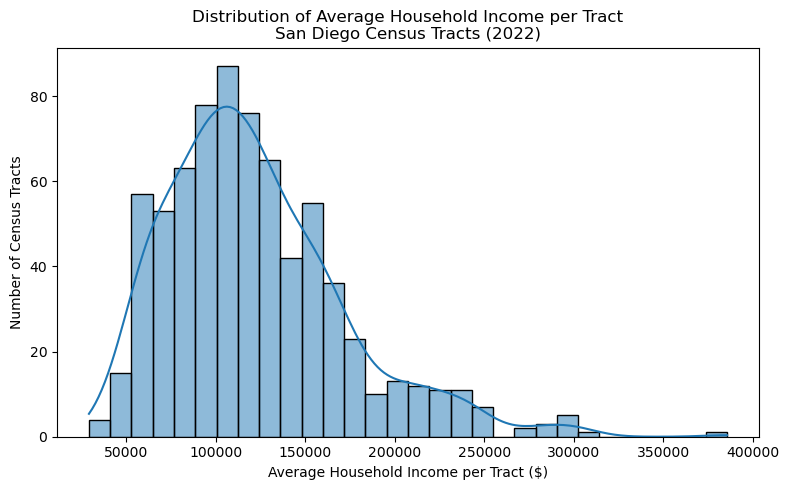

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df_sd_clean["income_per_hh"], bins=30, kde=True)
plt.xlabel("Average Household Income per Tract ($)")
plt.ylabel("Number of Census Tracts")
plt.title("Distribution of Average Household Income per Tract\nSan Diego Census Tracts (2022)")
plt.tight_layout()
plt.show()

The distribution of average household income across San Diego census tracts is moderately right-skewed. Most tracts cluster between approximately $80,000 and $150,000, with a peak around $100,000–$120,000. A smaller number of tracts extend into much higher income levels above the $200,000 level, creating a long upper tail that reaches nearly $400,000. This skewness indicates meaningful income disparity across neighborhoods and suggests that extreme high-income tracts may influence later analysis of emissions. Overall, the distribution confirms that San Diego contains a broad spectrum of tract-level income levels suitable for examining income and emissions relationships.

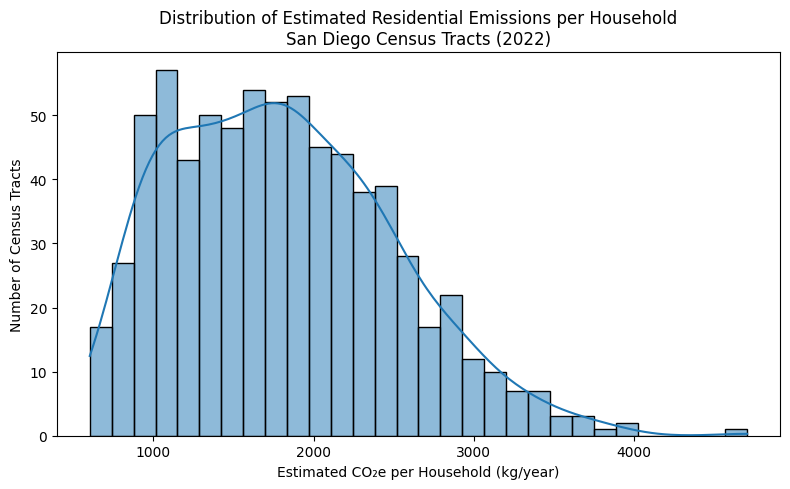

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(df_sd_clean["co2e_per_hh_kg"], bins=30, kde=True)
plt.xlabel("Estimated CO₂e per Household (kg/year)")
plt.ylabel("Number of Census Tracts")
plt.title("Distribution of Estimated Residential Emissions per Household\nSan Diego Census Tracts (2022)")
plt.tight_layout()
plt.show()

Estimated residential carbon emissions per household display a unimodal distribution centered roughly between 1,500 and 2,000 kg CO₂e per year. The distribution is mildly right-skewed, with most tracts falling between approximately 1,000 and 2,500 kg per household. A smaller number of higher emission tracts extend beyond 3,000 kg and up to nearly 4,700 kg, forming an upper tail. Compared to income, emissions appear more tightly concentrated, though still sufficiently dispersed to allow for meaningful variation across tracts. This variability supports the feasibility of detecting systematic relationships between income and emissions. We may want to explore some transformations for improved modeling.

#### Bernico part Section 2 of EDA - (Please remove this later, just make it be in 1 section, I only keep this here so it's easy to check my work)

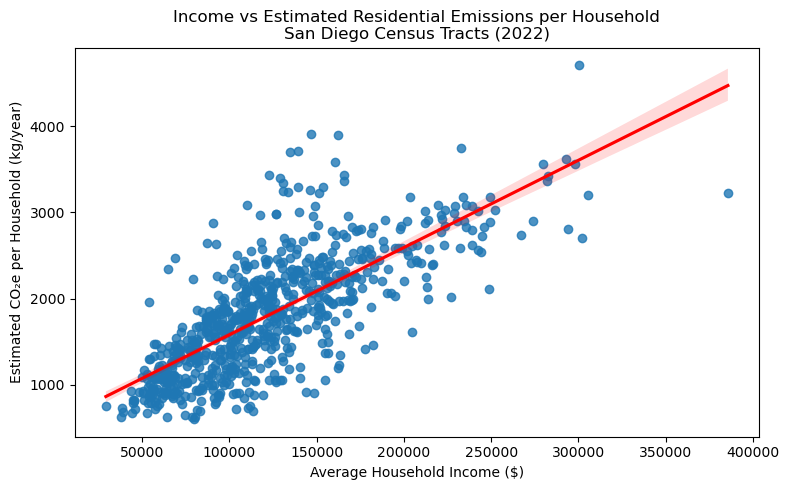

In [5]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df_sd_clean,
    x="income_per_hh",
    y="co2e_per_hh_kg",
    line_kws={"color":"red"}
    )

plt.title("Income vs Estimated Residential Emissions per Household\nSan Diego Census Tracts (2022)")
plt.xlabel("Average Household Income ($)")
plt.ylabel("Estimated CO₂e per Household (kg/year)")
plt.tight_layout()
plt.show()

The scatter plot shows a clear positive linear relationship between average household income and estimated residential CO₂e emissions per household. As income increases, estimated emissions per household tend to increase as well. The fitted regression line indicates a strong upward trend, suggesting that higher-income tracts generally have higher residential carbon footprints.

Most tracts cluster between roughly $80,000 and $150,000 in average income and between about 1,000 and 2,500 kg CO₂e per household, with variability widening at higher income levels (mild heteroskedasticity). A smaller number of high-income tracts (above $250,000) exhibit emissions exceeding 3,000 kg and in some cases approaching 4,500 kg, contributing to a right tail in both income and emissions. However, there is also an outlier data point that shows around $380,000 income tract (the highest in our dataset), but only exhibits emissions around 3,000 kg; this is most likely noise, as this data point is the only one that is notably distant from the overall positive trend and falls substantially below the regression line relative to other high-income tracts.

Overall, the pattern suggests a statistically meaningful and approximately linear association, supporting the hypothesis that household income is a strong predictor of residential carbon emissions in this dataset.

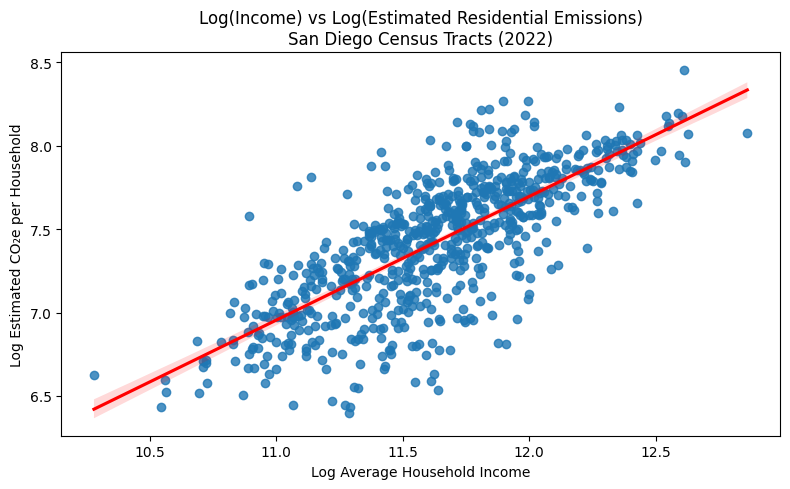

In [37]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df_sd_clean,
    x="log_income",
    y="log_co2e",
    line_kws={"color":"red"}
)

plt.title("Log(Income) vs Log(Estimated Residential Emissions)\nSan Diego Census Tracts (2022)")
plt.xlabel("Log Average Household Income")
plt.ylabel("Log Estimated CO₂e per Household")
plt.tight_layout()
plt.show()

The log–log scatter plot of average household income and estimated residential CO₂e emissions per household reveals a strong and approximately linear positive relationship across San Diego census tracts (2022). After log transformation, the association appears more structurally linear compared to the raw scale, with the previously noticeable highest-income data point appearing less visually deviant from the overall trend. No single observation exerts disproportionate visual influence in the transformed graph.

In log space, estimated emissions range roughly from 6.5 to 8.5 (log kg CO₂e per household), while log average household income spans approximately 10 to 13. The majority of tracts cluster between 7 and 8 log emissions and 11 to 12 log income. While this central concentration is partly a mathematical consequence of logarithmic compression of the original right-skewed distributions, it also reflects the underlying distribution of middle-income census tracts in the dataset.

Variability appears lowest among middle-income tracts and increases toward both the lower and upper ends of the income distribution. This pattern suggests that while emissions scale proportionally with income on average, greater heterogeneity exists among the lowest- and highest-income tracts. Importantly, compared to the raw-scale model, variance appears more symmetric and less systematically increasing with income, indicating that the log transformation improves homoscedasticity. This is on top of the fact that the variance at each ends of the transformed graph are generally also smaller compared to the raw graph.

Overall, the log–log specification supports a proportional interpretation of the relationship: percentage increases in income are associated with percentage increases in residential emissions. The improved linearity, reduced visual presence of the extreme observation, and more stable variance structure suggest that the log–log model may provide a more statistically appropriate and interpretable framework for regression analysis in this context, although both specifications yield substantively similar conclusions.

#### Paige part Section 3 of EDA - change title

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [38]:
# Paige Code


## Ethics

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Team Expectations 

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Project Timeline Proposal

Instructions: Replace this with your timeline.  **PLEASE UPDATE your Timeline!** No battle plan survives contact with the enemy, so make sure we understand how your plans have changed.  Also if you have lost points on the previous checkpoint fix them